In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import SpectralClustering
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [16]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [17]:
# 8.Clusstering Spectral Algorithms

In [18]:
df = df.drop(columns='CustomerID')

In [19]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


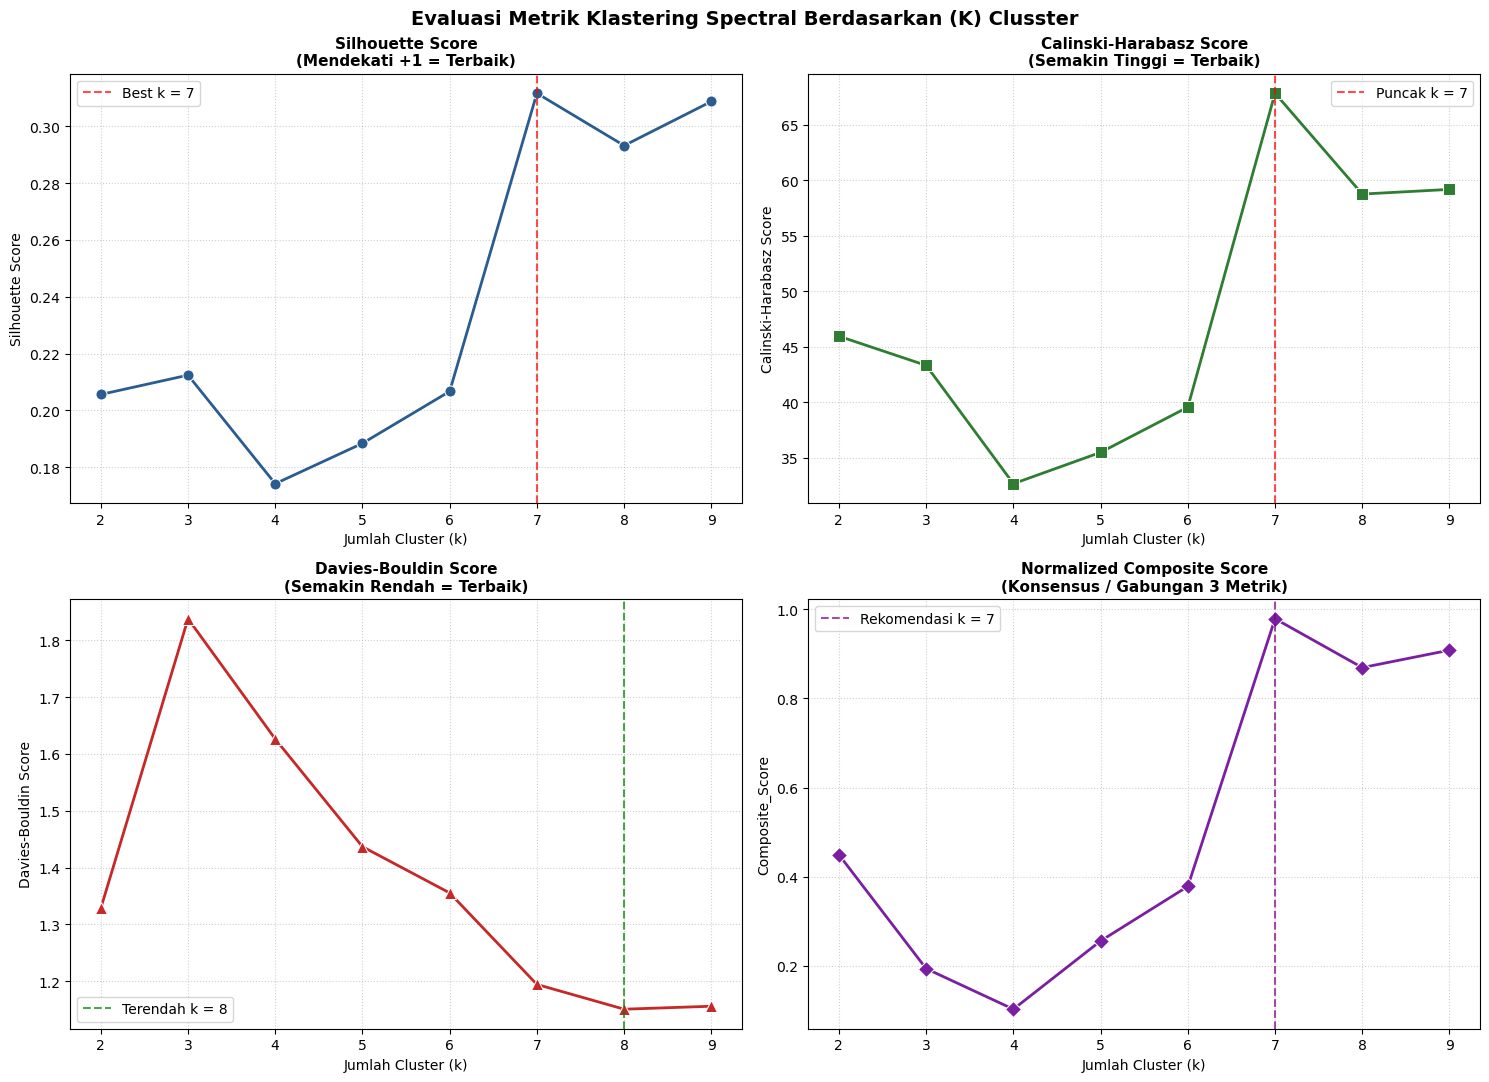

,n_clusters(k),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,0.205602,45.947617,1.328309,0.449294
1,3,0.212405,43.319227,1.838014,0.193677
2,4,0.174183,32.666395,1.626335,0.102660
3,5,0.188397,35.487637,1.436775,0.255807
4,6,0.206690,39.559553,1.355375,0.378245
5,7,0.311649,67.826460,1.194297,0.978857
6,8,0.293228,58.747994,1.150701,0.869264
7,9,0.308756,59.168940,1.155917,0.908378


In [20]:
sil_scores = []
ch_scores = []
db_scores = []
k_range = range(2, 10)

for k in k_range:
    spc = SpectralClustering(n_clusters=k, random_state=42, affinity='nearest_neighbors')
    model_spc = spc.fit_predict(X_cleaned)
    sil_scores.append(silhouette_score(X_cleaned, model_spc))
    ch_scores.append(calinski_harabasz_score(X_cleaned, model_spc))
    db_scores.append(davies_bouldin_score(X_cleaned, model_spc))

df_scores = pd.DataFrame({
    'n_clusters(k)': list(k_range),
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})

scaler = MinMaxScaler()
norm_sil = scaler.fit_transform(df_scores[['Silhouette Score']])
norm_ch = scaler.fit_transform(df_scores[['Calinski-Harabasz Score']])
norm_db = 1 - scaler.fit_transform(df_scores[['Davies-Bouldin Score']])
df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Silhouette Score (Mendekati +1 Lebih Baik) ---
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 0].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Plot 2: Calinski-Harabasz Score (Makin Tinggi Lebih Baik) ---
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[0, 1].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Plot 3: Davies-Bouldin Score (Makin Rendah Lebih Baik) ---
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 0].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Plot 4 (BARU): Normalized Composite Score (Gabungan 3 Metrik) ---
best_k_comp = int(df_scores.loc[df_scores['Composite_Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 1], x='n_clusters(k)', y='Composite_Score', data=df_scores, marker='D', markersize=8, linewidth=2, color='#7b1fa2')
axes[1, 1].axvline(x=best_k_comp, color='purple', linestyle='--', alpha=0.7, label=f'Rekomendasi k = {best_k_comp}')
axes[1, 1].set_title('Normalized Composite Score\n(Konsensus / Gabungan 3 Metrik)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Cluster (k)')
axes[1, 1].set_xticks(list(k_range))
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.suptitle('Evaluasi Metrik Klastering Spectral Berdasarkan (K) Clusster', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
df_scores